# Figure XX homer selection

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
import seaborn as sns
import scipy
from statannotations.Annotator import Annotator
import rushd as rd
import re
from pathlib import Path
import matplotlib

# Required descriptors for annotate
from scipy.stats import ttest_ind
from statannotations.stats.StatTest import StatTest
custom_long_name = 't-test for independent samples from scipy with greater 1-way (mean of the distribution underlying the first sample is greater than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_greater'
custom_func = ttest_ind
ttest_ind_greater = StatTest(custom_func, custom_long_name, custom_short_name, alternative='greater')

custom_long_name = 't-test for independent samples from scipy with less 1-way (mean of the distribution underlying the first sample is less than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_less'
custom_func = ttest_ind
ttest_ind_less = StatTest(custom_func, custom_long_name, custom_short_name, alternative='less')

In [ ]:
yaml_path_1_2 = rd.datadir/'data'/'attune'/'Maria'/'2026.07.22_homer_selection'/'Rep1_2'/'Single_cell_csvs'/'wells.yaml'
yaml_path_3_wt = rd.datadir/'data'/'attune'/'Maria'/'2026.07.22_homer_selection'/'Rep3_WT'/'Single_cell_csvs'/'wells.yaml'
yaml_path_ctrls = rd.datadir/'data'/'attune'/'Maria'/'2026.07.22_homer_selection'/'Ctrls'/'Single_cell_csvs'/'wells.yaml'
rd.plot.plot_well_metadata(yaml_path_ctrls)  

OSError: [Errno 22] Invalid argument: 'C:\\Users\\Grad2024\\Nextcloud\\data\\attune\\Maria\\2026.07.22_homer_selection\\Ctrls\\Single_cell_csvs\\wells.yaml'

In [ ]:
data_path_1_2 = rd.datadir/'data'/'attune'/'Maria'/'2026.07.22_homer_selection'/'Rep1_2'/'Single_cell_csvs'
data_path_3_wt = rd.datadir/'data'/'attune'/'Maria'/'2026.07.22_homer_selection'/'Rep3_WT'/'Single_cell_csvs'
data_path_ctrls = rd.datadir/'data'/'attune'/'Maria'/'2026.07.22_homer_selection'/'Ctrls'/'Single_cell_csvs'

In [ ]:
df_1_2 = rd.flow.load_csv_with_metadata(data_path_1_2, yaml_path_1_2)

In [ ]:
df_3_wt = rd.flow.load_csv_with_metadata(data_path_3_wt, yaml_path_3_wt)

In [ ]:
df_ctrls = rd.flow.load_csv_with_metadata(data_path_ctrls, yaml_path_ctrls)

In [ ]:
df = pd.concat([df_1_2, df_3_wt, df_ctrls], ignore_index=True)

In [ ]:
# df.loc[df['GFP-A'] <=0, 'GFP-A'] = 1
# df.loc[df['GFP-H'] <=0, 'GFP-H'] = 1
# df.loc[df['mRuby2-A'] <=0, 'mRuby2-A'] = 1
# df.loc[df['mRuby2-H'] <=0, 'mRuby2-H'] = 1
# df.loc[df['iRFP670-A'] <=0, 'iRFP670-A'] = 1
# df.loc[df['iRFP670-H'] <=0, 'iRFP670-H'] = 1

In [ ]:
df_log_friendly = df.loc[( df["GFP-A"] > 0) & (df["mRuby2-A"] > 0)]

In [ ]:
numSamples = 10**4
small_data_all = df_log_friendly.groupby(['cond']).sample(n=numSamples, random_state=1)

In [ ]:
df_no_GFP = df[(df['moi'] == 0)& (df['cond'] != 'Puro-GFP')]
df_no_mruby = df[df['cond'] == 'none']
gfp_threshold = df_no_GFP['GFP-A'].quantile(0.9995)
mruby_threshold = df_no_mruby['mRuby2-A'].quantile(0.9995)

Setting threshold for GFP and mRuby

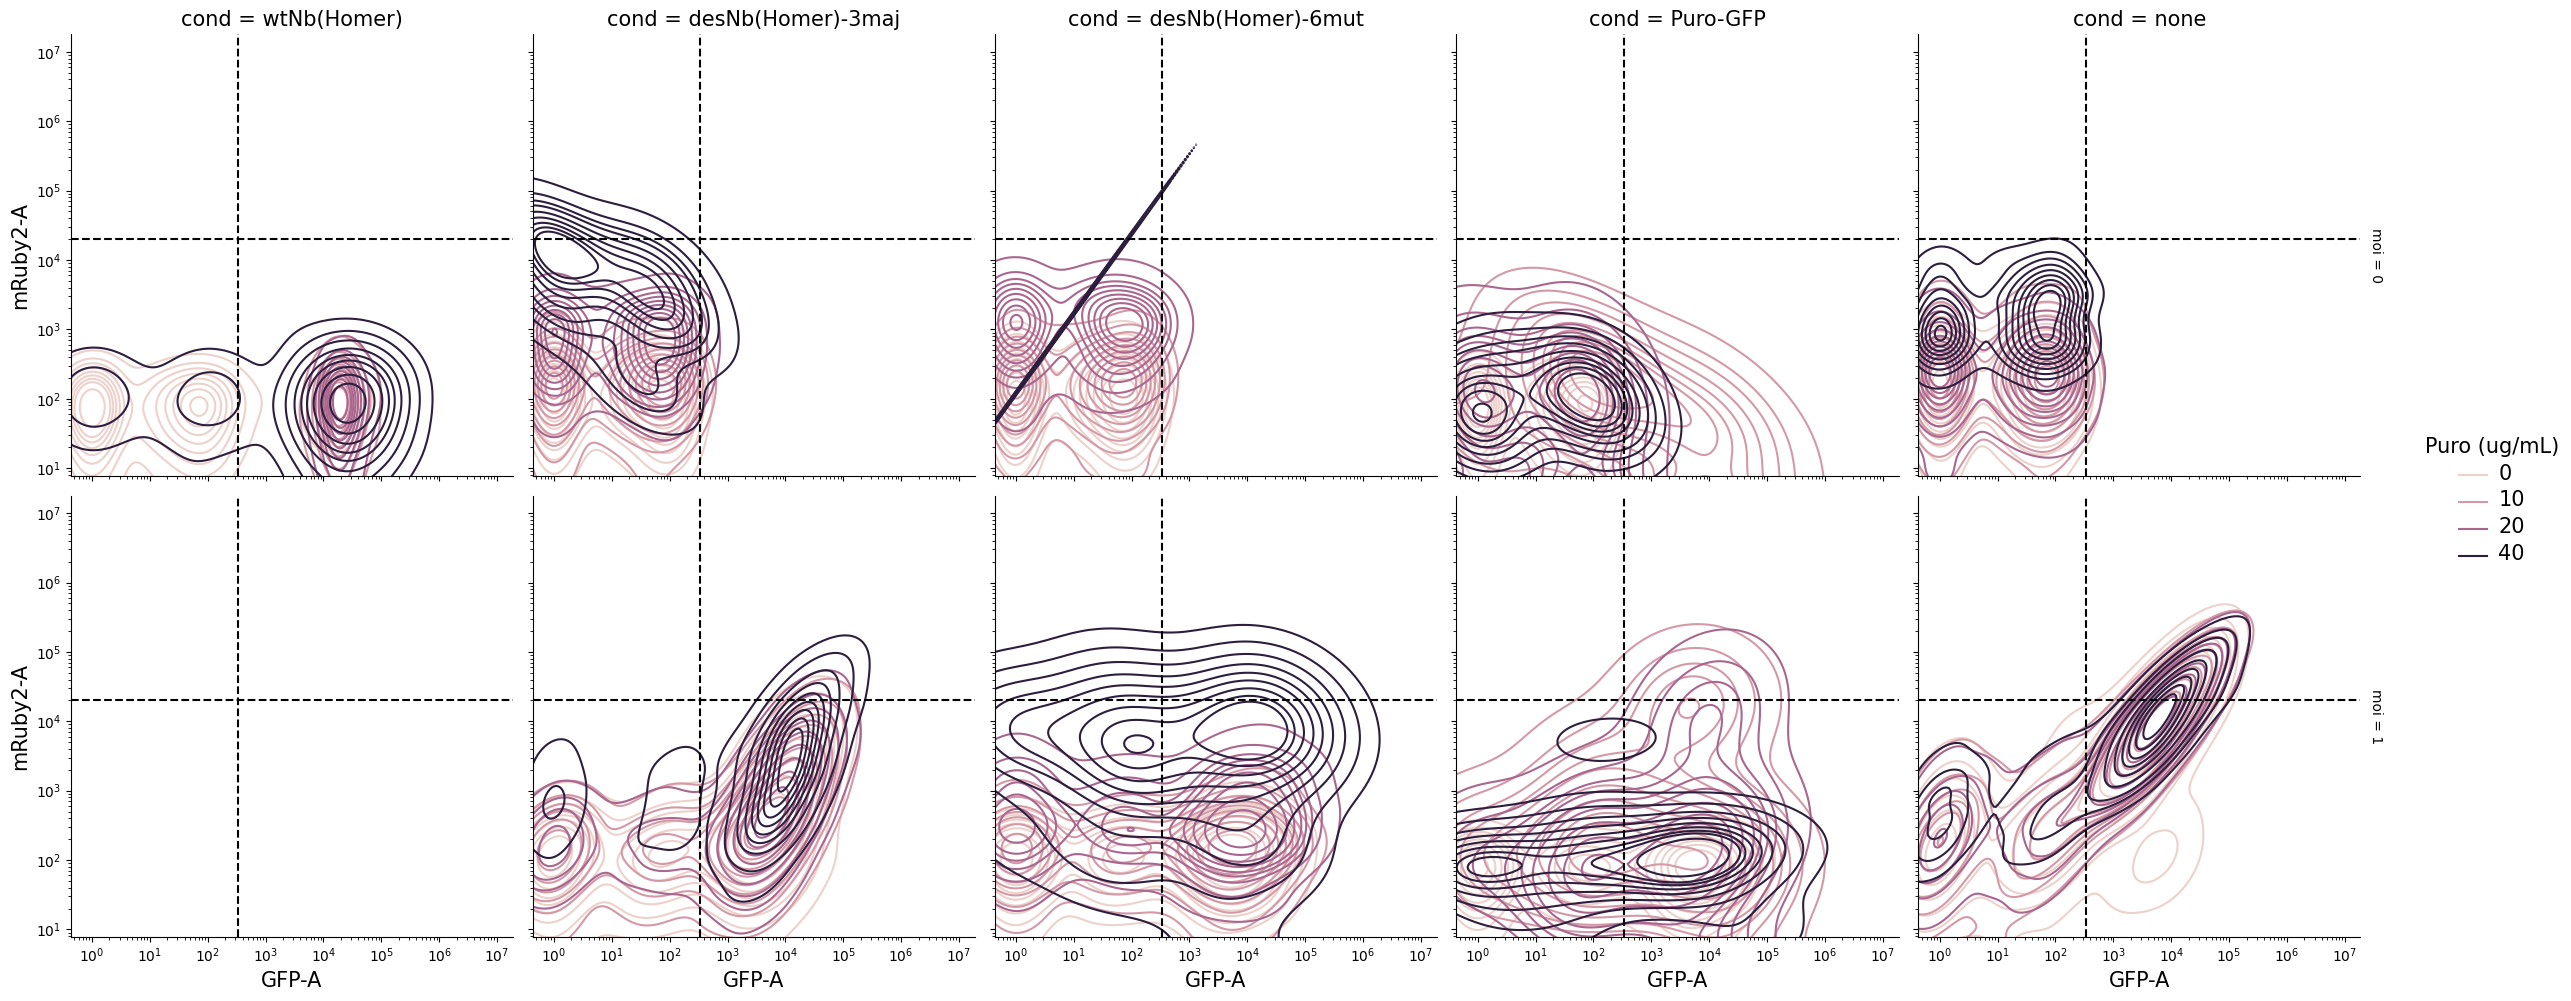

In [ ]:
cond_order = ['wtNb(Homer)', 'desNb(Homer)-3maj', 'desNb(Homer)-6mut', 'Puro-GFP', 'none']
small_data_all['cond'] = pd.Categorical(
    small_data_all['cond'], 
    categories=cond_order, 
    ordered=True
)

g = sns.displot(data = small_data_all, x = 'GFP-A', y = 'mRuby2-A', hue = 'puro', row = 'moi',col = 'cond', log_scale=True, common_norm=False, kind='kde', facet_kws=dict(margin_titles=True))
ax_vlines = [ax.axvline(gfp_threshold, color='black', linestyle='--') for ax in g.axes.flatten()]
ax_hlines = [ax.axhline(mruby_threshold, color='black', linestyle='--') for ax in g.axes.flatten()]
ax_xfontsizes = [ax.set_xlabel(ax.get_xlabel(), fontsize=15) for ax in g.axes.flatten()]
ax_yfontsizes = [ax.set_ylabel(ax.get_ylabel(), fontsize=15) for ax in g.axes.flatten()]
ax_titles = [ax.set_title(ax.get_title(), fontsize=15) for ax in g.axes.flatten()]
ax_row_titles = [ax.set_title(ax.get_title(), fontsize=15) for ax in g.axes[:,0]]

# Change the legend title
g.legend.set_title("Puro (ug/mL)")

# Change font sizes
plt.setp(g.legend.get_texts(), fontsize=15)
g.legend.get_title().set_fontsize(15)


Summary stats

In [ ]:
summary_dfs = []
groupby_cols = ['cond', 'puro', 'biorep', 'well', 'moi']
sc_count = df.groupby(groupby_cols).size().reset_index(name = "sc_count")
mruby_count = df.groupby(groupby_cols).apply(lambda df: sum(df['mRuby2-A'] > mruby_threshold)).reset_index(name = "mruby_count")
gfp_count = df.groupby(groupby_cols).apply(lambda df: sum(df['GFP-A'] >gfp_threshold)).reset_index(name = "gfp_count")



dfiii = sc_count.merge(mruby_count)
dfii = dfiii.merge(gfp_count)
dfii["purity"] = dfii['gfp_count'] / dfii['sc_count']*100
summary_dfs.append(dfii)

summary_df = pd.concat(summary_dfs, ignore_index=True)

In [ ]:
figpath = "C:/Users/Grad2024/Downloads/"

Combined MOI 1 Homer-GFP + MOI 0.1 Puro-GFP

C:\Users\Grad2024\AppData\Local\Temp\ipykernel_82732\234296569.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


Puro-GFP_0 vs. Puro-GFP_40: ****
11.0×
none_0 vs. none_40: *
1.0×
desNb(Homer)-6mut_0 vs. desNb(Homer)-6mut_40: ****
1.1×
wtNb(Homer)_0 vs. wtNb(Homer)_40: ****
1.4×
desNb(Homer)-3maj_0 vs. desNb(Homer)-3maj_40: ****
1.7×


C:\Users\Grad2024\AppData\Local\Temp\ipykernel_82732\234296569.py:143: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map[t.get_text()] for t in ax.get_xticklabels()])


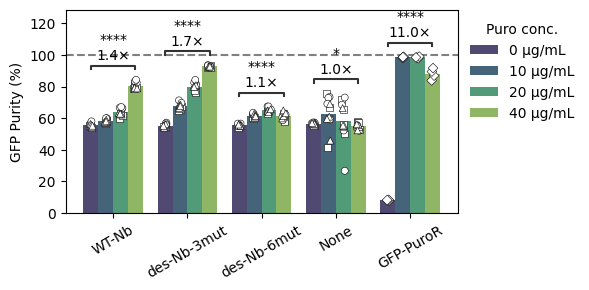

In [ ]:
palette = ['#4B4279', '#3C6682', '#45A778', '#8FC456']
hue = 'puro'
hue_order = [0, 10, 20, 40]
# General plotting params
x = 'cond'
y = 'purity'
order = ["wtNb(Homer)", "desNb(Homer)-3maj", 'desNb(Homer)-6mut', "none", "Puro-GFP"]

subset = summary_df[(summary_df['moi'] == 1) | (summary_df['cond'] == 'Puro-GFP')]

# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))

markers={1: 's', 2: 'o', 3: '^', 0: 'D'}
# Plot
sns.barplot(
    ax=ax, data=subset,
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)

for rep, marker in markers.items():
    sns.stripplot(ax=ax,
        data=subset[subset['biorep'] == rep],     x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker=marker,
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,legend = False

    )

    
# Formatting
ax.yaxis.set_label_text('GFP Purity (%)')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '10': '10 µg/mL',  '20': '20 µg/mL',  '40': '40 µg/mL'}
handles, labels = ax.get_legend_handles_labels()

# Keep first occurrence only
unique = dict(zip(labels, handles))

# Replace labels
new_labels = [lmap[str(label)] for label in unique.keys()]

ax.legend(
    unique.values(),
    new_labels,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)
 

ax.axhline(100, 0, 1, color='grey', linestyle='--')
ax.set_ylim(0, 110)

ax.tick_params(axis='x', labelrotation=30)

pairs = [
         (('wtNb(Homer)', 0), ('wtNb(Homer)', 40)),
         (('desNb(Homer)-3maj', 0), ('desNb(Homer)-3maj', 40)),
            (('desNb(Homer)-6mut', 0), ('desNb(Homer)-6mut', 40)),
            (('Puro-GFP', 0), ('Puro-GFP', 40)),
            (('none', 0), ('none', 40))
        

         ]


# Build one annotation string for each pair
annotations = []

for (g1, h1), (g2, h2) in pairs:

    vals1 = subset.loc[
        (subset[x] == g1) &
        (subset[hue] == h1),
        y
    ]

    vals2 = subset.loc[
        (subset[x] == g2) &
        (subset[hue] == h2),
        y
    ]

    # t-test
    _, p = ttest_ind(vals1, vals2)

    # convert p-value to stars
    if p < 1e-4:
        stars = "****"
    elif p < 1e-3:
        stars = "***"
    elif p < 1e-2:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    # fold change (second group / first group)
    fc = vals2.mean() / vals1.mean()

    # annotation text
    annotations.append(f"{stars}\n{fc:.1f}×")


annotator = Annotator(
    ax,
    pairs=pairs,
    data=subset,
    x=x,
    y=y,
    hue=hue,
    order=order,
    hue_order=hue_order,
)

annotator.configure(
    test='t-test_ind',
    text_format='full',   # use our custom text
    loc='inside',
    line_height=0.02,
    text_offset=2
)


annotator.set_custom_annotations(annotations)
annotator.annotate()

label_map = {
    'wtNb(Homer)': 'WT-Nb',
    'desNb(Homer)-3maj': 'des-Nb-3mut',
    'desNb(Homer)-6mut': 'des-Nb-6mut',
    'Puro-GFP': 'GFP-PuroR',
    'none': 'None'
}

ax.set_xticklabels([label_map[t.get_text()] for t in ax.get_xticklabels()])

fig.tight_layout()

fig.savefig(figpath+
    "homer1_purity.svg",
    format="svg",
    bbox_inches="tight"
)


C:\Users\Grad2024\AppData\Local\Temp\ipykernel_82732\118321400.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Puro-GFP_0 vs. Puro-GFP_40: t-test independent samples, P_val:9.334e-08 t=2.987e+01
none_0 vs. none_40: t-test independent samples, P_val:1.646e-11 t=1.256e+01
desNb(Homer)-6mut_0 vs. desNb(Homer)-6mut_40: t-test independent samples, P_val:3.673e-13 t=1.522e+01
wtNb(Homer)_0 vs. wtNb(Homer)_40: t-test independent samples, P_val:1.546e-01 t=1.474e+00
desNb(Homer)-3maj_0 vs. desNb(Homer)-3maj_40: t-test independent samples, P_val:6.517e-07 t=6.883e+00


C:\Users\Grad2024\AppData\Local\Temp\ipykernel_82732\118321400.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map[t.get_text()] for t in ax.get_xticklabels()])


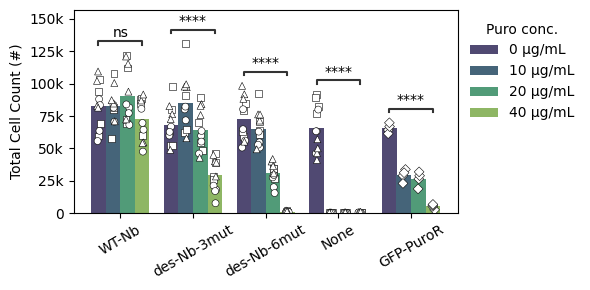

In [ ]:
palette = ['#4B4279', '#3C6682', '#45A778', '#8FC456']
hue = 'puro'
hue_order = [0, 10, 20, 40]
# General plotting params
x = 'cond'
y = 'sc_count'
order = ["wtNb(Homer)", "desNb(Homer)-3maj", 'desNb(Homer)-6mut', "none", "Puro-GFP"]

subset = summary_df[(summary_df['moi'] == 1) | (summary_df['cond'] == 'Puro-GFP')]

# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))

markers={1: 's', 2: 'o', 3: '^', 0: 'D'}
# Plot
sns.barplot(
    ax=ax, data=subset,
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)

for rep, marker in markers.items():
    sns.stripplot(ax=ax,
        data=subset[subset['biorep'] == rep],     x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker=marker,
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,legend = False

    )
    

# Formatting
ax.yaxis.set_label_text('Total Cell Count (#)')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '10': '10 µg/mL',  '20': '20 µg/mL',  '40': '40 µg/mL'}
handles, labels = ax.get_legend_handles_labels()

# Keep first occurrence only
unique = dict(zip(labels, handles))

# Replace labels
new_labels = [lmap[str(label)] for label in unique.keys()]

ax.legend(
    unique.values(),
    new_labels,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)
 
ax.tick_params(axis='x', labelrotation=30)

pairs = [
         (('wtNb(Homer)', 0), ('wtNb(Homer)', 40)),
         (('desNb(Homer)-3maj', 0), ('desNb(Homer)-3maj', 40)),
            (('desNb(Homer)-6mut', 0), ('desNb(Homer)-6mut', 40)),
            (('Puro-GFP', 0), ('Puro-GFP', 40)),
            (('none', 0), ('none', 40))
        

         ]


annotator = Annotator(
    plt.gca(),
    pairs=pairs, order = order,
    data= subset,
    x=x,
    y=y,
    hue = hue
)

annotator.configure(test='t-test_ind', text_format='star', loc='inside')
annotator.apply_and_annotate()

label_map = {
    'wtNb(Homer)': 'WT-Nb',
    'desNb(Homer)-3maj': 'des-Nb-3mut',
    'desNb(Homer)-6mut': 'des-Nb-6mut',
    'Puro-GFP': 'GFP-PuroR',
    'none': 'None'
}

ax.set_xticklabels([label_map[t.get_text()] for t in ax.get_xticklabels()])

fig.tight_layout()

fig.savefig(
    figpath+"homer1_total_cell_count.svg",
    format="svg",
    bbox_inches="tight"
)


Just looking at Homer1-GFP MOI 1

C:\Users\Grad2024\AppData\Local\Temp\ipykernel_82732\958156151.py:17: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

none_0 vs. none_40: t-test independent samples, P_val:2.376e-02 t=2.429e+00
desNb(Homer)-6mut_0 vs. desNb(Homer)-6mut_40: t-test independent samples, P_val:1.921e-08 t=-8.551e+00
wtNb(Homer)_0 vs. wtNb(Homer)_40: t-test independent samples, P_val:3.895e-21 t=-3.633e+01
desNb(Homer)-3maj_0 vs. desNb(Homer)-3maj_40: t-test independent samples, P_val:1.454e-31 t=-1.090e+02


Text(0.5, 0.98, 'Homer1 MOI 1')

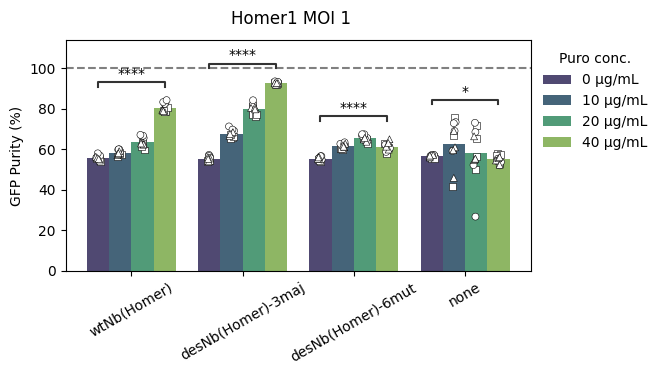

In [ ]:
palette = ['#4B4279', '#3C6682', '#45A778', '#8FC456']
summary_df_01 = summary_df[summary_df['moi'] == 1]
hue = 'puro'
hue_order = [0, 10, 20, 40]
# General plotting params
x = 'cond'
y = 'purity'
order = ["wtNb(Homer)", "desNb(Homer)-3maj", 'desNb(Homer)-6mut', "none"]

summary_df_01 = summary_df[summary_df['moi'] == 1]

# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))

markers={1: 's', 2: 'o', 3: '^', 0: 'D'}
# Plot
sns.barplot(
    ax=ax, data=summary_df_01,
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)

for rep, marker in markers.items():
    sns.stripplot(ax=ax,
        data=summary_df_01[summary_df_01['biorep'] == rep],     x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker=marker,
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,legend = False

    )


# Formatting
ax.yaxis.set_label_text('GFP Purity (%)')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '10': '10 µg/mL',  '20': '20 µg/mL',  '40': '40 µg/mL'}
handles, labels = ax.get_legend_handles_labels()

# Keep first occurrence only
unique = dict(zip(labels, handles))

# Replace labels
new_labels = [lmap[str(label)] for label in unique.keys()]

ax.legend(
    unique.values(),
    new_labels,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)

ax.axhline(100, 0, 1, color='grey', linestyle='--')
ax.set_ylim(0, 110)

ax.tick_params(axis='x', labelrotation=30)

pairs = [
         (('wtNb(Homer)', 0), ('wtNb(Homer)', 40)),
         (('desNb(Homer)-3maj', 0), ('desNb(Homer)-3maj', 40)),
            (('desNb(Homer)-6mut', 0), ('desNb(Homer)-6mut', 40)),
            (('none', 0), ('none', 40))
        

         ]


annotator = Annotator(
    plt.gca(),
    pairs=pairs, order = order,
    data= summary_df_01,
    x=x,
    y=y,
    hue = hue
)

annotator.configure(test='t-test_ind', text_format='star', loc='inside')
annotator.apply_and_annotate()

# Format
plt.suptitle('Homer1 MOI 1')


Just looking at MOI 0 for Homer1-GFP

C:\Users\Grad2024\AppData\Local\Temp\ipykernel_82732\969457880.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Puro-GFP_0 vs. Puro-GFP_40: t-test independent samples, P_val:6.042e-09 t=-4.723e+01
none_0 vs. none_40: t-test independent samples, P_val:4.520e-02 t=-2.521e+00
desNb(Homer)-6mut_0 vs. desNb(Homer)-6mut_40: t-test independent samples, P_val:1.532e-01 t=-1.683e+00
wtNb(Homer)_0 vs. wtNb(Homer)_40: t-test independent samples, P_val:8.414e-03 t=-3.855e+00
desNb(Homer)-3maj_0 vs. desNb(Homer)-3maj_40: t-test independent samples, P_val:3.688e-03 t=-4.601e+00


Text(0.5, 0.98, 'Homer1 MOI 0')

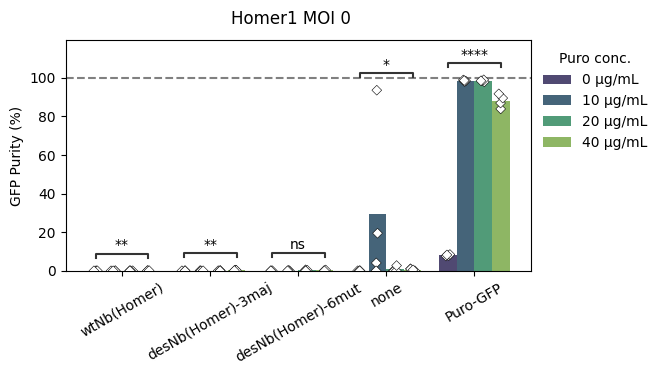

In [ ]:
summary_df_0 = summary_df[summary_df['moi'] == 0]

hue = 'puro'
x = 'cond'
y = 'purity'

order = ["wtNb(Homer)", "desNb(Homer)-3maj", 'desNb(Homer)-6mut', "none", "Puro-GFP"]

# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))
# Plot
sns.barplot(
    ax=ax, data=summary_df_0,
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)

for rep, marker in markers.items():
    sns.stripplot(ax=ax,
        data=summary_df_0[summary_df_0['biorep'] == rep],     x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker=marker,
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,legend = False

    )
    

# Formatting
# ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.yaxis.set_label_text('GFP Purity (%)')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '10': '10 µg/mL',  '20': '20 µg/mL',  '40': '40 µg/mL'}
handles, labels = ax.get_legend_handles_labels()

# Keep first occurrence only
unique = dict(zip(labels, handles))

# Replace labels
new_labels = [lmap[str(label)] for label in unique.keys()]

ax.axhline(100, 0, 1, color='grey', linestyle='--')
ax.set_ylim(0, 110)

ax.legend(
    unique.values(),
    new_labels,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)

pairs = [
         (('wtNb(Homer)', 0), ('wtNb(Homer)', 40)),
         (('desNb(Homer)-3maj', 0), ('desNb(Homer)-3maj', 40)),
            (('desNb(Homer)-6mut', 0), ('desNb(Homer)-6mut', 40)),
            (('Puro-GFP', 0), ('Puro-GFP', 40)),
            (('none', 0), ('none', 40))
        

         ]


annotator = Annotator(
    plt.gca(),
    pairs=pairs, order = order,
    data= summary_df_0,
    x=x,
    y=y,
    hue = hue
)

annotator.configure(test='t-test_ind', text_format='star', loc='inside')
annotator.apply_and_annotate()

ax.tick_params(axis='x', labelrotation=30)
# Format
plt.suptitle('Homer1 MOI 0')

C:\Users\Grad2024\AppData\Local\Temp\ipykernel_82732\3120731616.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


Text(0.5, 0.98, 'Homer1 MOI 1')

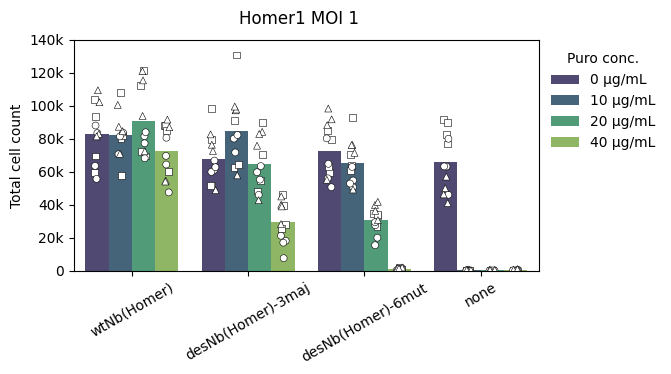

In [ ]:
y = 'sc_count'

hue = 'puro'

order = ["wtNb(Homer)", "desNb(Homer)-3maj", 'desNb(Homer)-6mut', "none"]

# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))
# Plot
sns.barplot(
    ax=ax, data=summary_df_01,
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)

for rep, marker in markers.items():
    sns.stripplot(ax=ax,
        data=summary_df_01[summary_df_01['biorep'] == rep],     x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker=marker,
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,legend = False

    )
    

# Formatting
# ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.yaxis.set_label_text('Total cell count')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '10': '10 µg/mL',  '20': '20 µg/mL',  '40': '40 µg/mL'}
handles, labels = ax.get_legend_handles_labels()

# Keep first occurrence only
unique = dict(zip(labels, handles))

# Replace labels
new_labels = [lmap[str(label)] for label in unique.keys()]

ax.legend(
    unique.values(),
    new_labels,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)

plt.ylim(0, 140000)
ax.tick_params(axis='x', labelrotation=30)

# Format
plt.suptitle('Homer1 MOI 1')
# fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'bar_iMN-count.svg', bbox_inches='tight')

C:\Users\Grad2024\AppData\Local\Temp\ipykernel_82732\395251424.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


Text(0.5, 0.98, 'Homer1 MOI 0')

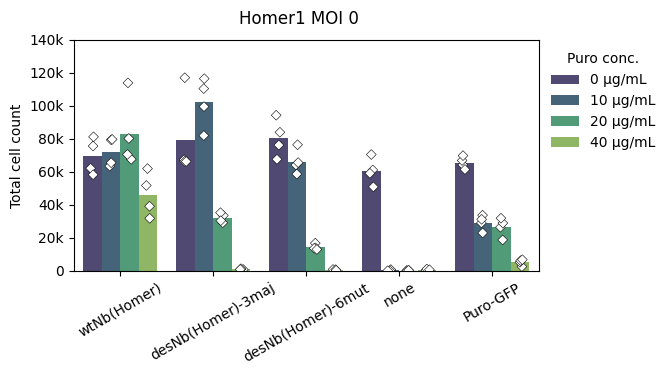

In [ ]:
y = 'sc_count'

hue = 'puro'
order = ["wtNb(Homer)", "desNb(Homer)-3maj", 'desNb(Homer)-6mut', "none", "Puro-GFP"]

# Plot iMN percent of all cells
fig, ax = plt.subplots(1, 1, figsize=(6,3))

# Plot
sns.barplot(
    ax=ax, data=summary_df_0,
    x=x, y=y, ci=None,
    order=order, hue=hue,
    palette=palette, alpha=1)

for rep, marker in markers.items():
    sns.stripplot(ax=ax,
        data=summary_df_0[summary_df_0['biorep'] == rep],     x=x, y=y,
    order=order, hue=hue,
    dodge=True, marker=marker,
    palette={puro:'white' for puro in hue_order}, size=5,
    edgecolor='black', linewidth=0.4,legend = False

    )

# sns.stripplot(
#     ax=ax, data=data_iMN_count_reps,
#     x=x, y=y,
#     order=order, hue=hue,
#     dodge=True, marker='o',
#     palette={puro:'white' for puro in hue_order}, size=5,
#     edgecolor='black', linewidth=0.4,legend = False)
    

# Formatting
# ax.yaxis.set_label_text('(%) iMN yield\nper MEF plated')
ax.yaxis.set_label_text('Total cell count')
ax.xaxis.set_label_text('')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
# legend
lmap = {'0': '0 µg/mL', '10': '10 µg/mL',  '20': '20 µg/mL',  '40': '40 µg/mL'}
handles, labels = ax.get_legend_handles_labels()

# Keep first occurrence only
unique = dict(zip(labels, handles))

# Replace labels
new_labels = [lmap[str(label)] for label in unique.keys()]

ax.legend(
    unique.values(),
    new_labels,
    title='Puro conc.',
    loc='upper left',
    bbox_to_anchor=(1,1),
    frameon=False
)


plt.ylim(0, 140000)
ax.tick_params(axis='x', labelrotation=30)

# Format
plt.suptitle('Homer1 MOI 0')
# fig.tight_layout()  # Helps improve white spacing
# plt.savefig(figpath + 'bar_iMN-count.svg', bbox_inches='tight')